In [ ]:
# Importing necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Change the directory from default directory used by python
os.chdir(r"C:\Users\Priyanka\Desktop\SEM5\IP")  
print(os.getcwd())

C:\Users\Priyanka\Desktop\SEM5\IP


In [25]:
# Load two smooth grayscale images
img1 = cv2.imread(r"C:\Users\Priyanka\Desktop\SEM5\IP\IP4.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(r"C:\Users\Priyanka\Desktop\SEM5\IP\Picture1.jpg", cv2.IMREAD_GRAYSCALE)

img = cv2.imread('IP5.jpeg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image 1 not loaded. Check file path and name.")

img = cv2.imread('IP4.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image 2 not loaded. Check file path and name.")
else:
    print("Proceed.")

Proceed.


In [26]:
# Matrix representation of the images
print("First image:\n", img1)
print("\nSecond image:\n", img2)

First image:
 [[108 108 109 ... 111 110 109]
 [108 109 109 ... 111 110 109]
 [109 109 110 ... 111 110 109]
 ...
 [102 107 112 ...  79  79  79]
 [ 94 102 112 ...  95  95  95]
 [ 98 106 115 ...  92  92  92]]

Second image:
 [[ 99  97  98 ...  98  99  99]
 [ 93  91  92 ...  92  93  93]
 [ 94  92  93 ...  93  94  94]
 ...
 [100  99  99 ... 104 105 105]
 [109 108 108 ... 114 114 114]
 [116 114 115 ... 120 120 120]]


In [27]:
# Normalizing the images
img1 = img1 / np.max(img1)
img2 = img2 / np.max(img2)

np.set_printoptions(precision=2, suppress=True)

In [28]:
# Sobel filter: gradient magnitude
def sobel_filter(img):
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])
    sobel_y = np.array([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]])
    
    # Dimensions
    img_h, img_w = img.shape
    sobel_x_h, sobel_x_w = sobel_x.shape
    sobel_y_h, sobel_y_w = sobel_y.shape

    # Size of the convolved matrix obtained by convolution with sobel_x
    output1_h = img_h   # - sobel_x_h + 1
    output1_w = img_w   # - sobel_x_w + 1

    # Size of the convolved matrix obtained by convolution with sobel_y
    output2_h = img_h   # - sobel_y_h + 1
    output2_w = img_w   # - sobel_y_w + 1

    # Initializing output matrix
    output1 = np.zeros(((output1_h, output1_w)),dtype=np.float64)
    output2 = np.zeros(((output2_h, output2_w)),dtype=np.float64)

    padded_img = np.pad(img, ((1, 1), (1, 1)), mode='edge')

    # Perform convolution
    for i in range(img_h):
        for j in range(img_w):
            # Extract region of interest
            region = padded_img[i:i+3, j:j+3]

            # Element-wise multiplication and sum
            output1[i, j] = np.sum(region * sobel_x)
            output2[i, j] = np.sum(region * sobel_y)
            
    magnitude = np.sqrt((output1**2 + output2**2))

    #print("Convolved output 1:\n", output1)
    #print("\nConvolved output 2:\n", output2)

    magnitude = np.uint8(255 * magnitude/ np.max(magnitude))
    return magnitude

In [29]:
# Laplacian filter
def laplacian_filter(img):
    laplacian = np.array([[0, 1, 0],
                          [1, -4, 1],
                          [0, 1, 0]])
    
    # Dimensions
    img_h, img_w = img.shape
    laplacian_h, laplacian_w = laplacian.shape

    # Size of the convolved matrix obtained by convolution with sobel_x
    output_h = img_h    # - laplacian_h + 1
    output_w = img_w    # - laplacian_w + 1

    # Initializing output matrix
    output = np.zeros(((output_h, output_w)) ,dtype=np.float64)
    
    padded_img = np.pad(img, ((1, 1), (1, 1)), mode='edge')

    # Perform convolution
    for i in range(img_h):
        for j in range(img_w):
            # Extract region of interest
            region = padded_img[i:i+3, j:j+3]
        
            # Element-wise multiplication and sum
            output[i, j] = np.sum(region * laplacian)

    # Take absolute value and convert to uint8
    output = np.uint8(255 * np.absolute(output) / np.max(np.absolute(output)))
    return output

In [ ]:
# Apply filters
sobel_img1 = sobel_filter(img1)
sobel_img2 = sobel_filter(img2)

laplacian_img1 = laplacian_filter(img1)
laplacian_img2 = laplacian_filter(img2)

print("The shape of the original images:\n", img1.shape, img2.shape)
print("\nThe shape of the sobel filtered images:\n", sobel_img1.shape, sobel_img2.shape)
print("\nThe shape of the Laplacian filtered images:\n", 
                    laplacian_img1.shape, laplacian_img2.shape)
print("\nHence, the shape of the filtered images is same as the shape of the original images.")

The shape of the original images:
 (408, 612) (426, 431)

The shape of the sobel filtered images:
 (408, 612) (426, 431)

The shape of the Laplacian filtered images:
 (408, 612) (426, 431)

Hence, the shape of the filtered images is same as the shape of the original images.


In [ ]:
# Normalizing the edge detected images
sobel_img1 = sobel_img1 / np.max(sobel_img1)
sobel_img2 = sobel_img2 / np.max(sobel_img2)

laplacian_img1 = laplacian_img1 / np.max(laplacian_img1)
laplacian_img2 = laplacian_img2 / np.max(laplacian_img2)

In [ ]:
# EDGE ENHANCEMENT
# enhanced image = original image + α * edge detected image
alpha = 0.5
final_sobel_img1 = img1 + alpha * sobel_img1   
final_sobel_img2 = img2 + alpha * sobel_img2

final_laplacian_img1 = img1 + alpha * laplacian_img1
final_laplacian_img2 = img2 + alpha * laplacian_img2

In [48]:
# Normalizing the edge enhanced images
final_sobel_img1 = final_sobel_img1 / np.max(final_sobel_img1)
final_sobel_img2 = final_sobel_img2 / np.max(final_sobel_img2)

final_laplacian_img1 = final_laplacian_img1 / np.max(final_laplacian_img1)
final_laplacian_img2 = final_laplacian_img2 / np.max(final_laplacian_img2)

np.set_printoptions(precision=2, suppress=True)

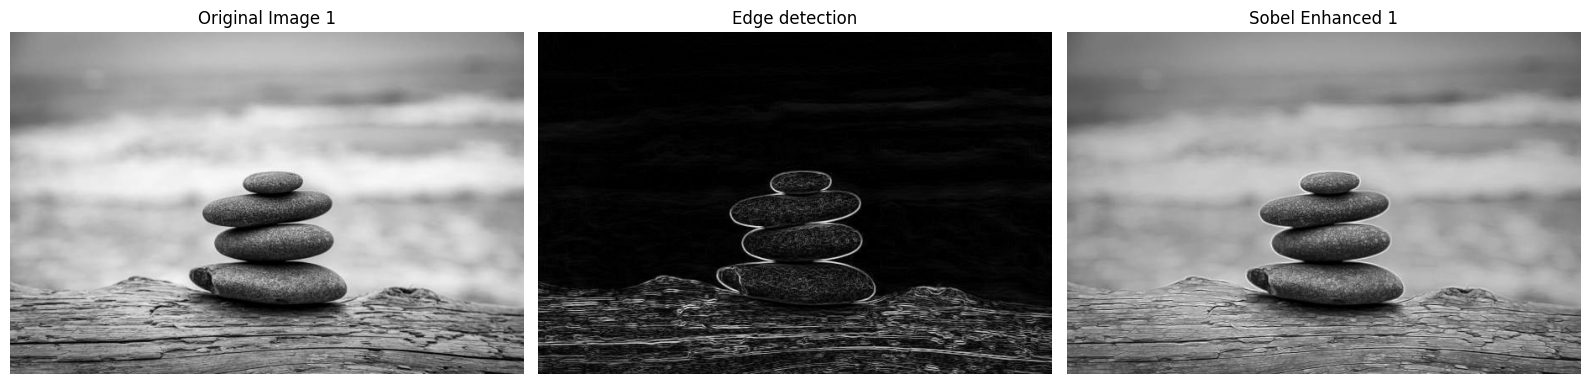

In [49]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 1')
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(sobel_img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Sobel Enhanced 1')
plt.imshow(final_sobel_img1, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

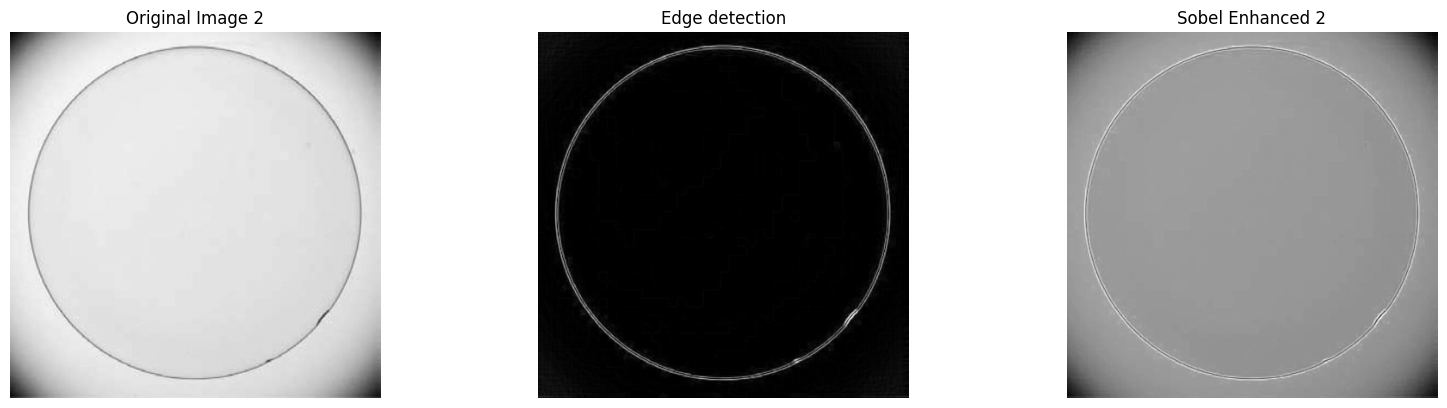

In [50]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 2')
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(sobel_img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Sobel Enhanced 2')
plt.imshow(final_sobel_img2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

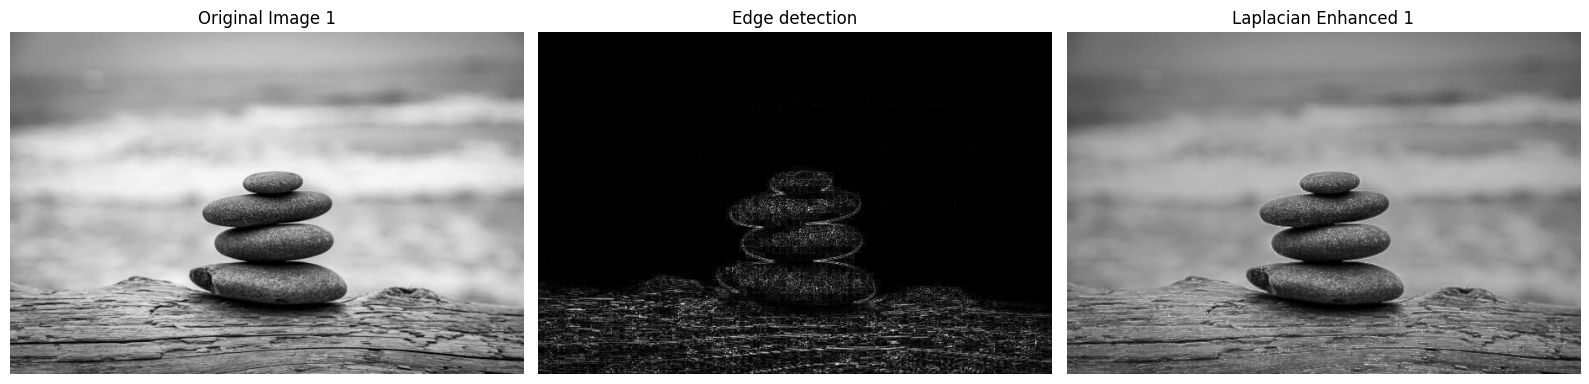

In [51]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 1')
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(laplacian_img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Laplacian Enhanced 1')
plt.imshow(final_laplacian_img1, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

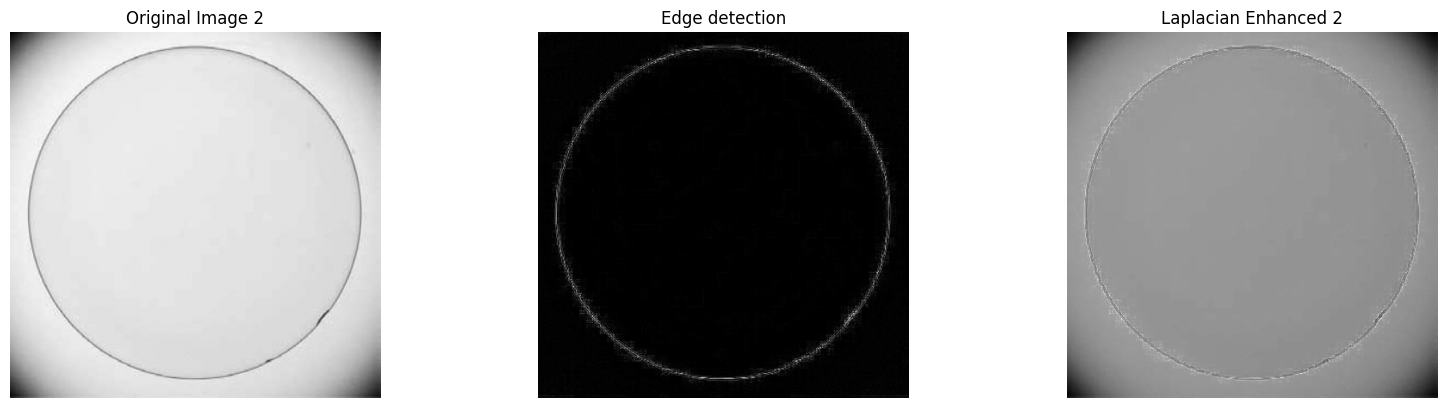

In [52]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 2')
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(laplacian_img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Laplacian Enhanced 2')
plt.imshow(final_laplacian_img2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
# VERIFICATION using OpenCV functions

# Sobel filter: gradient magnitude
def sobel_filter(img):
    sobel_x1 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y1 = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    magnitude1 = cv2.magnitude(sobel_x1, sobel_y1)
    magnitude1 = np.uint8(255 * magnitude1 / np.max(magnitude1))
    return magnitude1

In [38]:
# Laplacian filter
def laplacian_filter(img):
    laplacian1 = cv2.Laplacian(img, cv2.CV_64F)
    laplacian1 = np.uint8(255 * np.absolute(laplacian1) / np.max(np.absolute(laplacian1)))
    return laplacian1

In [39]:
# Apply filters
sobel_img11 = sobel_filter(img1)
sobel_img21 = sobel_filter(img2)
laplacian_img11 = laplacian_filter(img1)
laplacian_img21 = laplacian_filter(img2)

In [57]:
# Normalizing the edge detected images
sobel_img11 = sobel_img11 / np.max(sobel_img11)
sobel_img21 = sobel_img21 / np.max(sobel_img21)

laplacian_img11 = laplacian_img11 / np.max(laplacian_img11)
laplacian_img21 = laplacian_img21 / np.max(laplacian_img21)

In [ ]:
# EDGE ENHANCEMENT
# enhanced image = original image + α * edge detected image
alpha = 0.5
final_sobel_img11 = alpha * sobel_img11 + img1    
final_sobel_img21 = alpha * sobel_img21 + img2

final_laplacian_img11 = alpha * laplacian_img11 + img1
final_laplacian_img21 = alpha * laplacian_img21 + img2

In [59]:
# Normalizing the edge enhanced images
final_sobel_img11 = final_sobel_img11 / np.max(final_sobel_img11)
final_sobel_img21 = final_sobel_img21 / np.max(final_sobel_img21)

final_laplacian_img11 = final_laplacian_img11 / np.max(final_laplacian_img11)
final_laplacian_img21 = final_laplacian_img21 / np.max(final_laplacian_img21)

np.set_printoptions(precision=2, suppress=True)

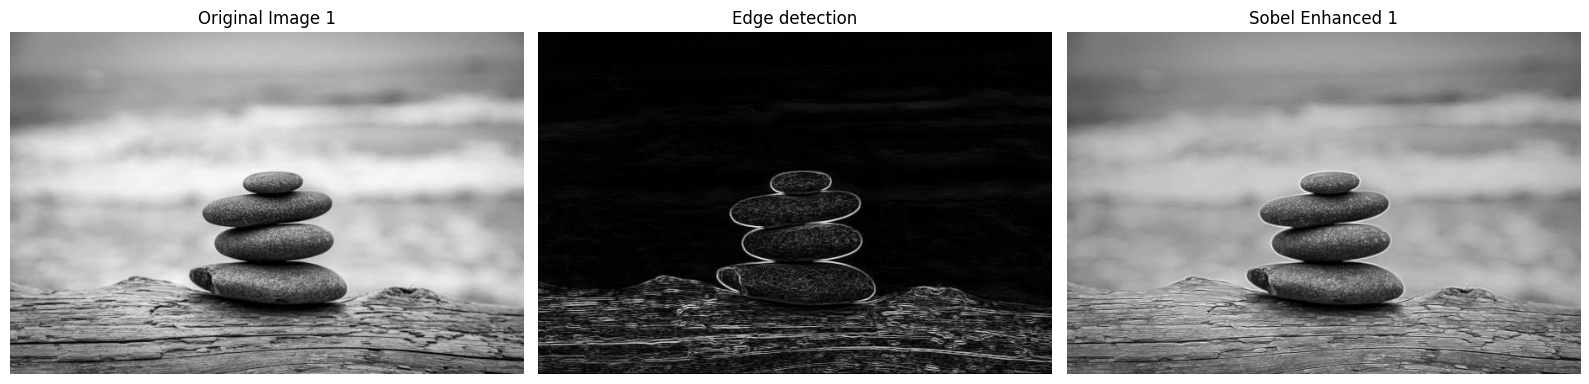

In [60]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 1')
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(sobel_img11, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Sobel Enhanced 1')
plt.imshow(final_sobel_img11, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

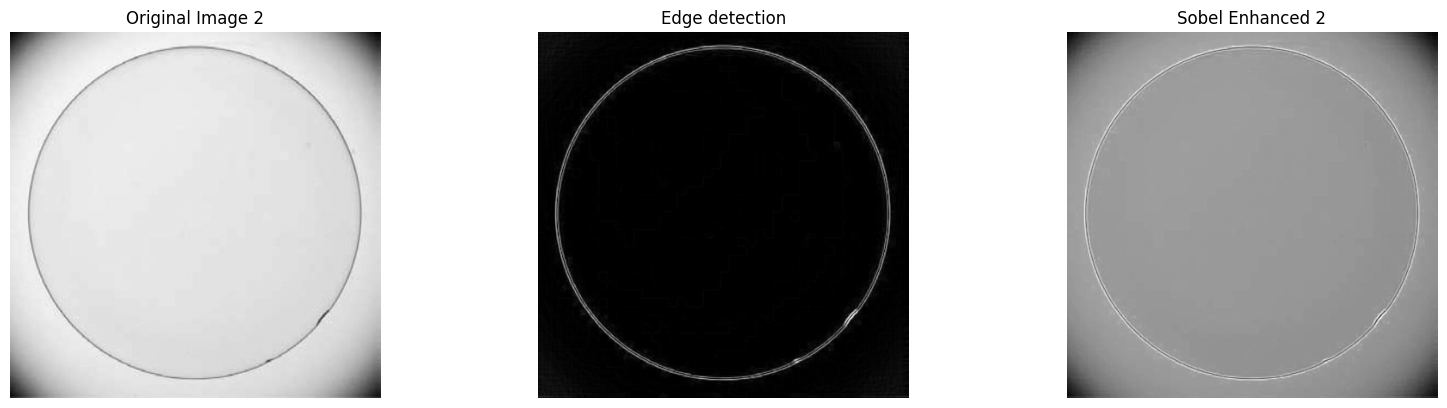

In [61]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 2')
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(sobel_img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Sobel Enhanced 2')
plt.imshow(final_sobel_img2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

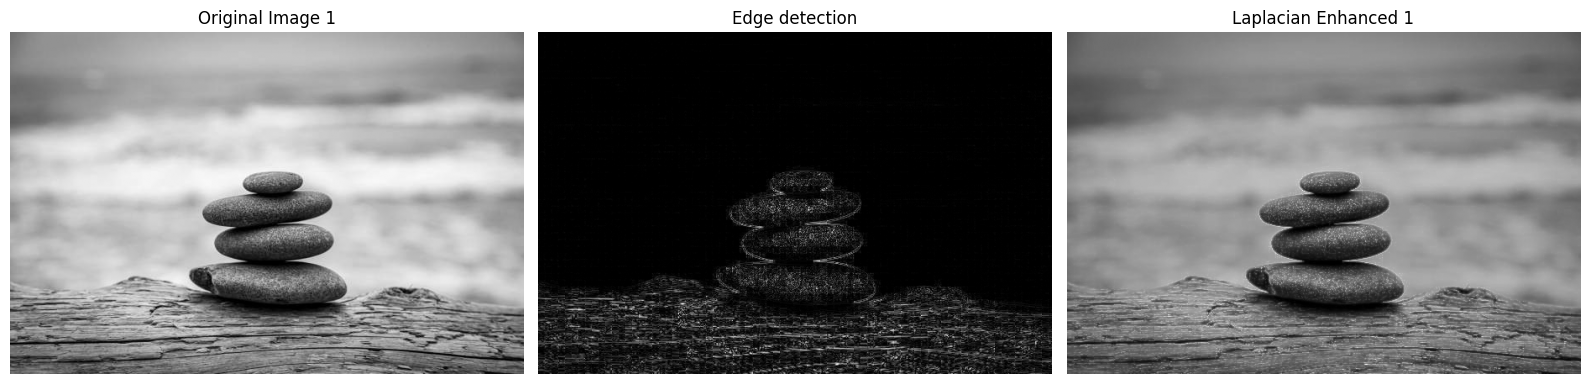

In [62]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 1')
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(laplacian_img11, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Laplacian Enhanced 1')
plt.imshow(final_laplacian_img11, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

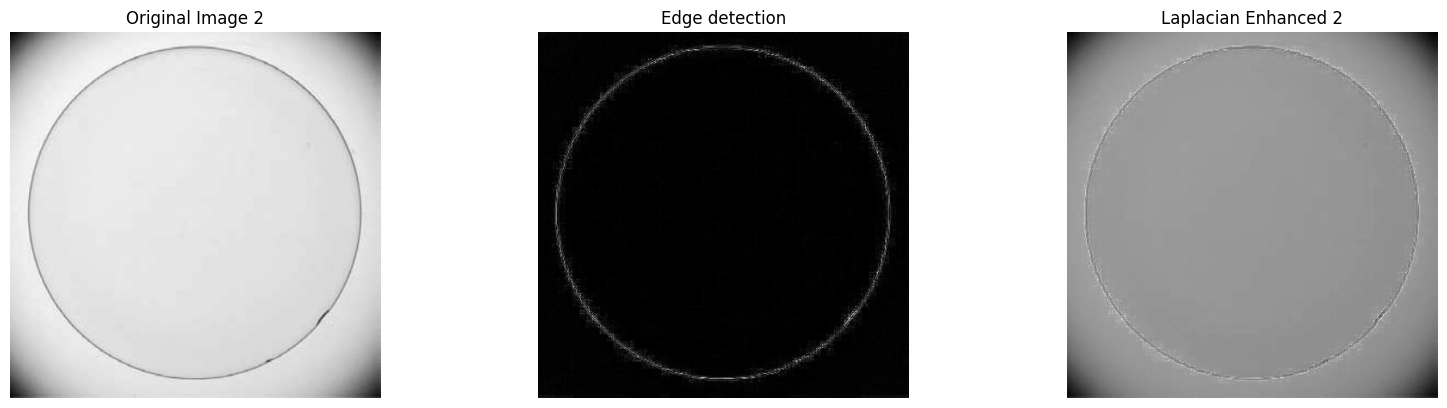

In [63]:
# Plot original and enhanced images
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title('Original Image 2')
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title('Edge detection')
plt.imshow(laplacian_img21, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title('Laplacian Enhanced 2')
plt.imshow(final_laplacian_img21, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()